## Previsão de Falencia de Pequenas Empresas

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# DICIONÁRIO COMPLETO DOS ATRIBUTOS

In [2]:
nomes_atributos = {
    "Attr1": "Lucro Líquido / Ativos Totais",
    "Attr2": "Passivo Total / Ativos Totais",
    "Attr3": "Capital de Giro / Ativos Totais",
    "Attr4": "Ativo Circulante / Passivo Circulante",
    "Attr5": "Lucros Retidos / Ativos Totais",
    "Attr6": "EBIT / Ativos Totais",
    "Attr7": "Patrimônio Líquido / Passivo Total",
    "Attr8": "Vendas / Ativos Totais",
    "Attr9": "Lucro Bruto / Ativos Totais",
    "Attr10": "Capital Próprio / Ativos Totais",
    "Attr11": "Lucro Operacional / Ativos Totais",
    "Attr12": "Lucro Bruto / Passivo de Curto Prazo",
    "Attr13": "Lucro Bruto / Vendas",
    "Attr14": "Lucro Operacional / Passivo Total",
    "Attr15": "Ativo Total / Passivo Total",
    "Attr16": "Lucro Bruto / Ativo Circulante",
    "Attr17": "Ativo Total / Passivo Circulante",
    "Attr18": "Lucro Bruto / Ativos Totais",
    "Attr19": "Lucro Bruto / Vendas Líquidas",
    "Attr20": "Estoque / Vendas",
    "Attr21": "Vendas / Contas a Receber",
    "Attr22": "Lucro Líquido / Vendas",
    "Attr23": "Lucro Líquido / Ativo Circulante",
    "Attr24": "Lucro Líquido / Estoque",
    "Attr25": "Patrimônio Líquido / Ativos Totais",
    "Attr26": "Lucros Retidos / Patrimônio Líquido",
    "Attr27": "Lucro Operacional / Patrimônio Líquido",
    "Attr28": "Capital de Giro / Passivo Total",
    "Attr29": "Logaritmo do Ativo Total",
    "Attr30": "Passivo Total / Vendas",
    "Attr31": "Lucro Operacional / Vendas",
    "Attr32": "Passivo Circulante / Estoque",
    "Attr33": "Passivo Circulante / Vendas",
    "Attr34": "Capital de Giro / Custos Operacionais",
    "Attr35": "Lucro Bruto / Depreciação",
    "Attr36": "Vendas / Ativo Total Médio",
    "Attr37": "Ativo Circulante / Ativo Total",
    "Attr38": "Lucro Líquido / Patrimônio Líquido",
    "Attr39": "Passivo de Longo Prazo / Ativos Totais",
    "Attr40": "Capital de Giro / Estoque",
    "Attr41": "Ativo Circulante / Passivo Total",
    "Attr42": "Ativo Circulante / Vendas",
    "Attr43": "Contas a Receber / Vendas",
    "Attr44": "Estoque / Ativo Circulante",
    "Attr45": "Estoque / Passivo Circulante",
    "Attr46": "Vendas / Estoque",
    "Attr47": "EBITDA / Ativos Totais",
    "Attr48": "EBITDA / Vendas",
    "Attr49": "EBITDA / Passivo Total",
    "Attr50": "Caixa / Passivo Total",
    "Attr51": "Caixa / Ativos Totais",
    "Attr52": "Caixa / Vendas",
    "Attr53": "Ativo Circulante / Receita Operacional",
    "Attr54": "Passivo Circulante / Ativo Total",
    "Attr55": "Passivo Circulante / Patrimônio Líquido",
    "Attr56": "Capital de Giro / Receita Operacional",
    "Attr57": "Lucro Operacional / Ativo Circulante",
    "Attr58": "Lucro Líquido / Passivo Total",
    "Attr59": "Lucro Líquido / Passivo Circulante",
    "Attr60": "Lucro Líquido / Capital de Giro",
    "Attr61": "Vendas / Patrimônio Líquido",
    "Attr62": "Passivo Total / Patrimônio Líquido",
    "Attr63": "Capital de Giro / Ativo Circulante",
    "Attr64": "Capital de Giro / Passivo Circulante",
    "class": "Situação da Empresa"
}

In [3]:
# LEITURA DAS 5 PLANILHAS CSV

arquivo1 = pd.read_csv("1year.csv", na_values="?")
arquivo2 = pd.read_csv("2year.csv", na_values="?")
arquivo3 = pd.read_csv("3year.csv", na_values="?")
arquivo4 = pd.read_csv("4year.csv", na_values="?")
arquivo5 = pd.read_csv("5year.csv", na_values="?")

# Junta tudo em um único dataframe
df = pd.concat(
    [arquivo1, arquivo2, arquivo3, arquivo4, arquivo5],
    ignore_index=True
)

print("Dataset completo carregado com sucesso.")
print(f"Total de linhas: {df.shape[0]}")
print(f"Total de colunas: {df.shape[1]}")

Dataset completo carregado com sucesso.
Total de linhas: 43405
Total de colunas: 65


In [4]:
# COLUNAS

df.rename(columns=nomes_atributos, inplace=True)

print("\nColunas.")
display(df.head())



Colunas.


,Lucro Líquido / Ativos Totais,Passivo Total / Ativos Totais,Capital de Giro / Ativos Totais,Ativo Circulante / Passivo Circulante,Lucros Retidos / Ativos Totais,EBIT / Ativos Totais,Patrimônio Líquido / Passivo Total,Vendas / Ativos Totais,Lucro Bruto / Ativos Totais,Capital Próprio / Ativos Totais,...,Capital de Giro / Receita Operacional,Lucro Operacional / Ativo Circulante,Lucro Líquido / Passivo Total,Lucro Líquido / Passivo Circulante,Lucro Líquido / Capital de Giro,Vendas / Patrimônio Líquido,Passivo Total / Patrimônio Líquido,Capital de Giro / Ativo Circulante,Capital de Giro / Passivo Circulante,Situação da Empresa
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


In [5]:
# TRATAMENTO DE VALORES NULOS

df = df.fillna(df.median(numeric_only=True))
print("Valores nulos tratados com mediana.")


Valores nulos tratados com mediana.


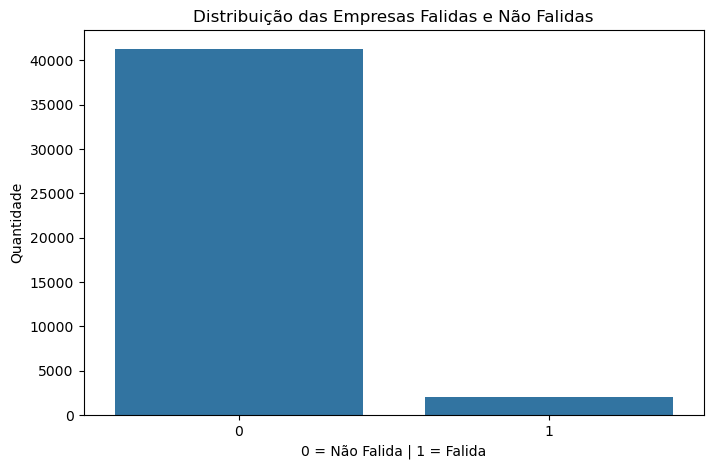

In [6]:
# DISTRIBUIÇÃO DA VARIÁVEL ALVO

plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Situação da Empresa")

plt.title("Distribuição das Empresas Falidas e Não Falidas")
plt.xlabel("0 = Não Falida | 1 = Falida")
plt.ylabel("Quantidade")
plt.show()

Interpretação:

Classe 0 → Empresas não falidas

Classe 1 → Empresas falidas

Este gráfico mostra se o dataset está desbalanceado.
Normalmente há muito mais empresas saudáveis do que falidas.

In [7]:
# CORRELAÇÃO
correlation = df.corr(numeric_only=True)
target_corr = correlation["Situação da Empresa"].sort_values(ascending=False)

print("\nTop 15 variáveis mais relacionadas com falência:")
display(target_corr.head(15))


Top 15 variáveis mais relacionadas com falência:


Situação da Empresa                       1.000000
Passivo Total / Ativos Totais             0.035227
Caixa / Ativos Totais                     0.034743
Passivo Circulante / Estoque              0.011561
Ativo Total / Passivo Total               0.005470
Passivo Circulante / Ativo Total          0.004627
Ativo Circulante / Receita Operacional    0.004604
Capital de Giro / Passivo Circulante      0.003146
Passivo Circulante / Vendas               0.002640
Ativo Circulante / Vendas                 0.001692
Capital de Giro / Receita Operacional     0.000949
EBITDA / Passivo Total                    0.000438
Capital de Giro / Custos Operacionais     0.000417
Capital de Giro / Estoque                 0.000312
Passivo Total / Vendas                    0.000228
Name: Situação da Empresa, dtype: float64

Calcula a relação entre todas as variáveis do dataset e a variável alvo “Situação da Empresa” (falida ou não falida). Ele mostra quais atributos estão mais ligados à falência, podendo ter correlação positiva (aumenta a chance de falência) ou negativa (diminui a chance). Serve para entender quais fatores mais influenciam o problema.

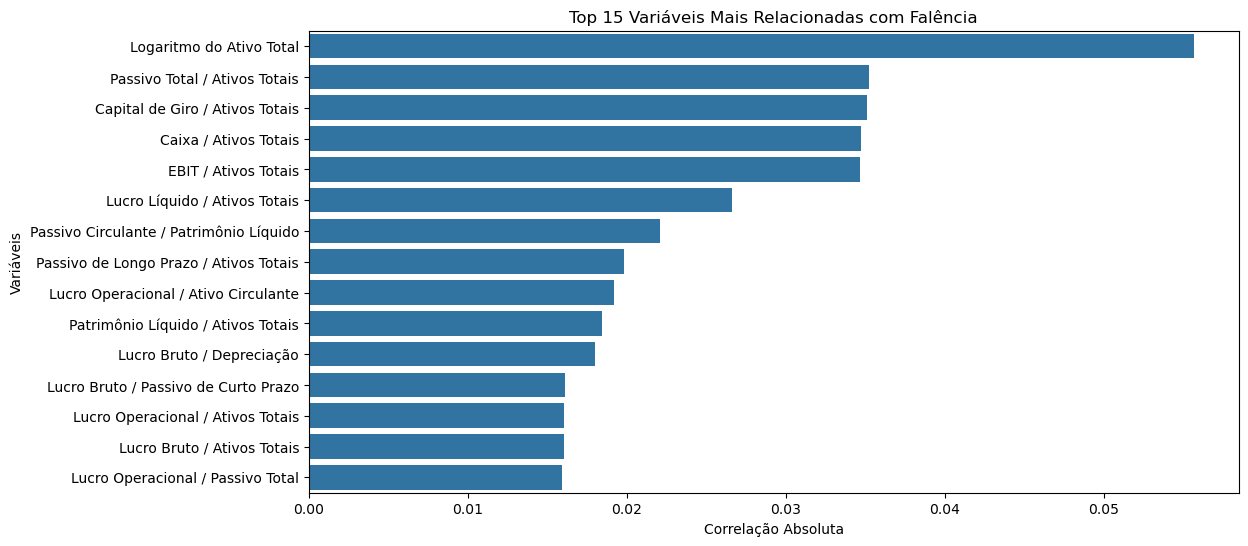

In [8]:
# TOP 10 VARIÁVEIS MAIS IMPORTANTES
top_corr = (target_corr.drop("Situação da Empresa")
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
sns.barplot(x=top_corr.values,y=top_corr.index)

plt.title("Top 15 Variáveis Mais Relacionadas com Falência")
plt.xlabel("Correlação Absoluta")
plt.ylabel("Variáveis")
plt.show()

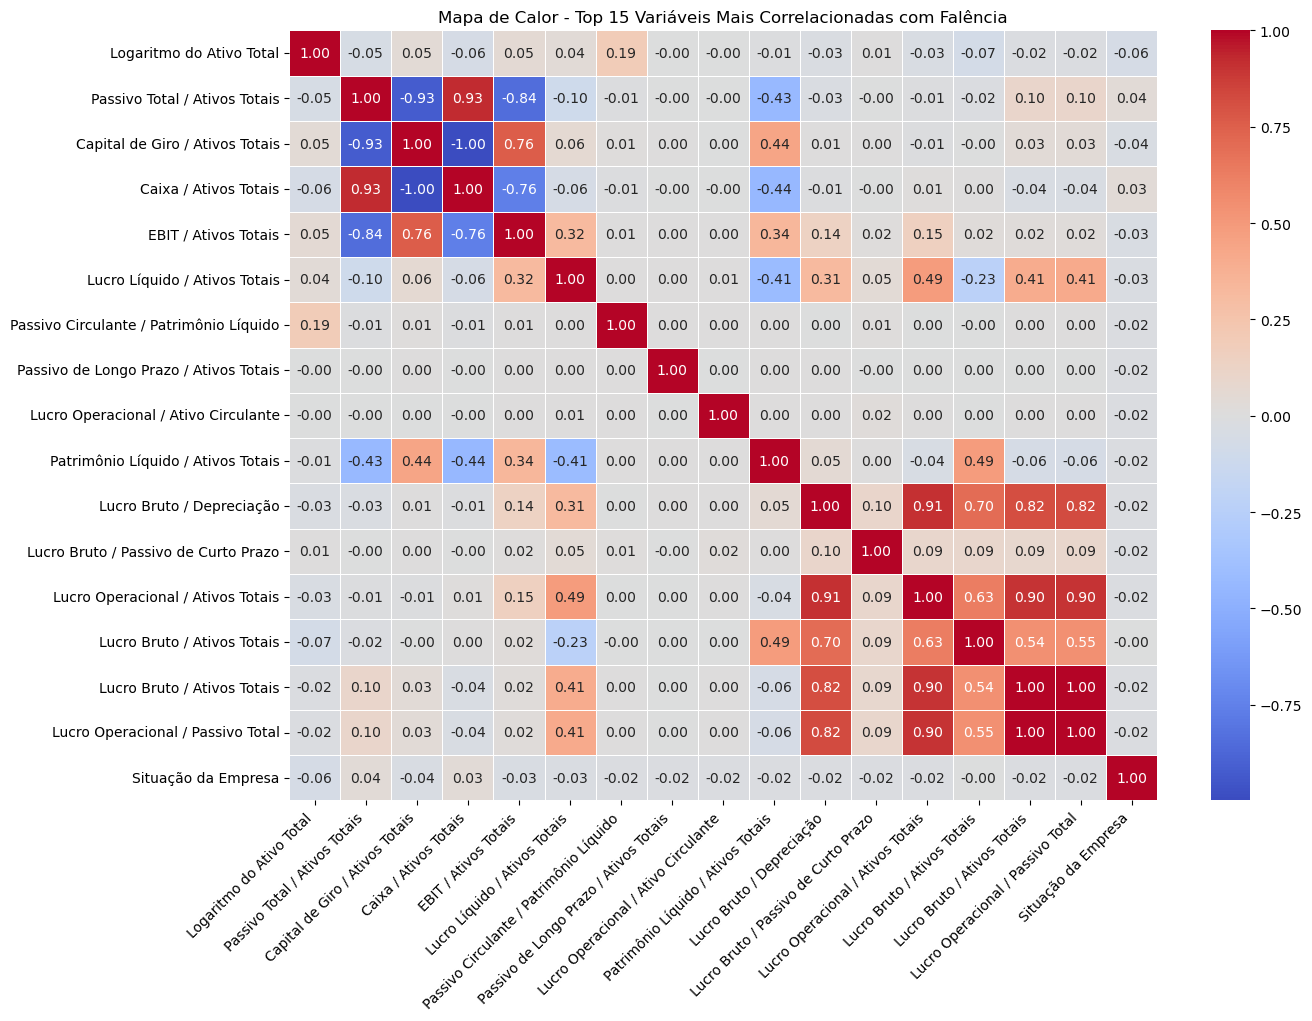

In [9]:
# GRÁFICO DE CALOR (HEATMAP)
top_15_corr = (
    target_corr
    .drop("Situação da Empresa")   
    .abs()                         
    .sort_values(ascending=False) 
    .head(15)                      
)
top_15_cols = list(top_15_corr.index)
top_15_cols.append("Situação da Empresa")
plt.figure(figsize=(14,10))

sns.heatmap(
    df[top_15_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Mapa de Calor - Top 15 Variáveis Mais Correlacionadas com Falência")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [10]:
df = df.loc[:, ~df.columns.duplicated()].copy()
df["Situação da Empresa"] = df["Situação da Empresa"].astype(int)

correlation = df.corr(numeric_only=True)
target_corr = (
    correlation["Situação da Empresa"]
    .drop("Situação da Empresa")
    .abs()
    .sort_values(ascending=False)
)
cols = list(target_corr.head(15).index)

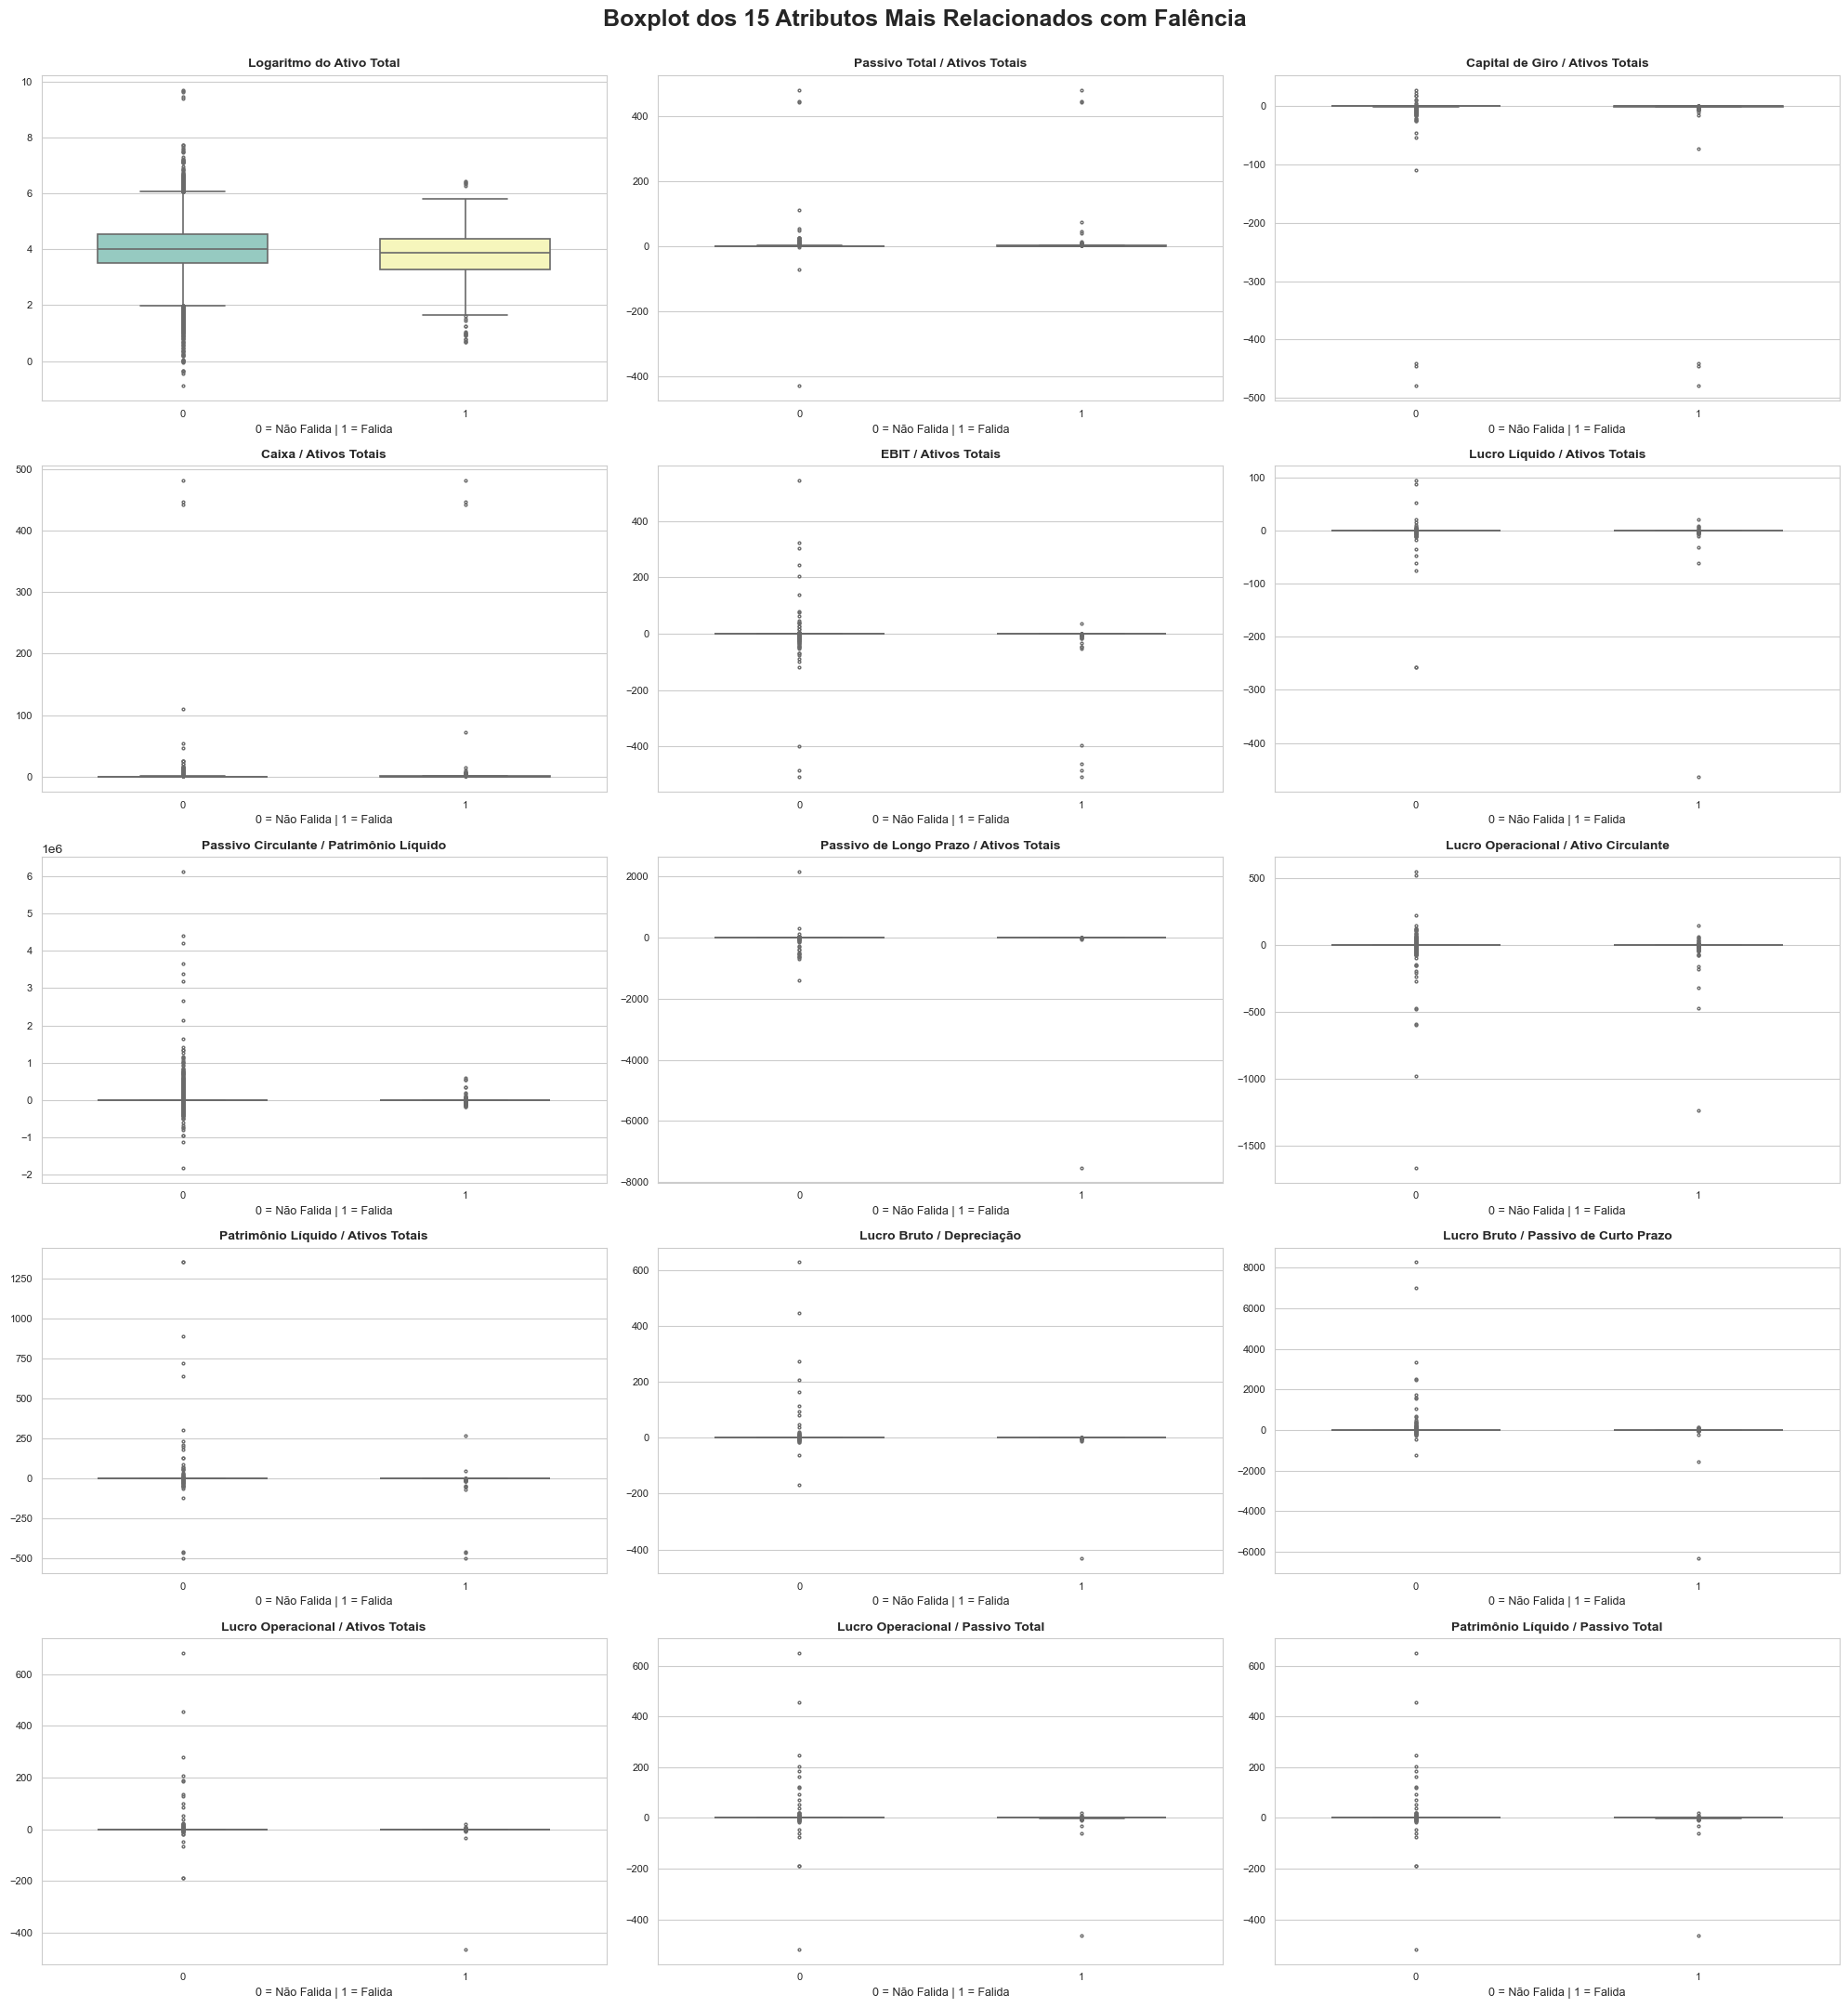

In [11]:
# BOXPLOT - DISPERSÃO CRÍTICA VS FALÊNCIA
sns.set_style("whitegrid")  # fundo mais bonito
fig, axes = plt.subplots(5, 3, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col] = pd.to_numeric(df[col], errors="coerce")
    sns.boxplot(
        data=df,
        x="Situação da Empresa",
        y=col,
        ax=axes[i],
        palette="Set3",     
        width=0.6,
        linewidth=1.2,
        fliersize=2         
    )
    axes[i].set_title(
        col,
        fontsize=10,
        fontweight="bold"
    )

    axes[i].set_xlabel(
        "0 = Não Falida | 1 = Falida",
        fontsize=9
    )

    axes[i].set_ylabel("")
    axes[i].tick_params(axis='x', labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Boxplot dos 15 Atributos Mais Relacionados com Falência",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Os boxplots dos 15 atributos mais correlacionados com a falência mostram diferenças visíveis entre empresas falidas e não falidas, indicando que essas variáveis realmente possuem forte relação com o risco de falência.

Empresas falidas (classe 1) tendem a apresentar piores indicadores financeiros, como menor rentabilidade, menor capital de giro e maior nível de endividamento. Já as empresas não falidas (classe 0) geralmente possuem distribuição mais estável e valores mais favoráveis nesses indicadores.

É possível identificar grande presença de outliers, algo comum em bases financeiras, já que algumas empresas possuem comportamentos muito fora do padrão.

Alguns atributos mostraram diferenças mais acentuadas entre os grupos, principalmente aqueles ligados à liquidez, lucro e relação entre passivos e ativos, reforçando que esses fatores são importantes para prever falência empresarial.

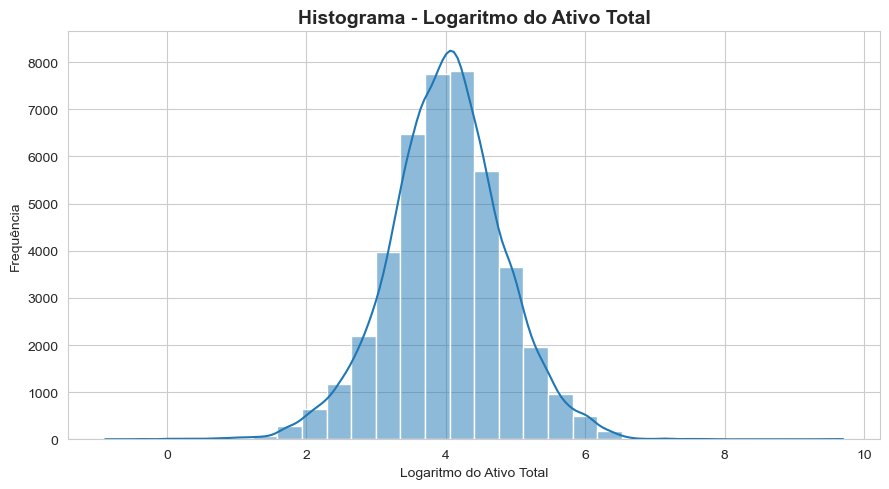

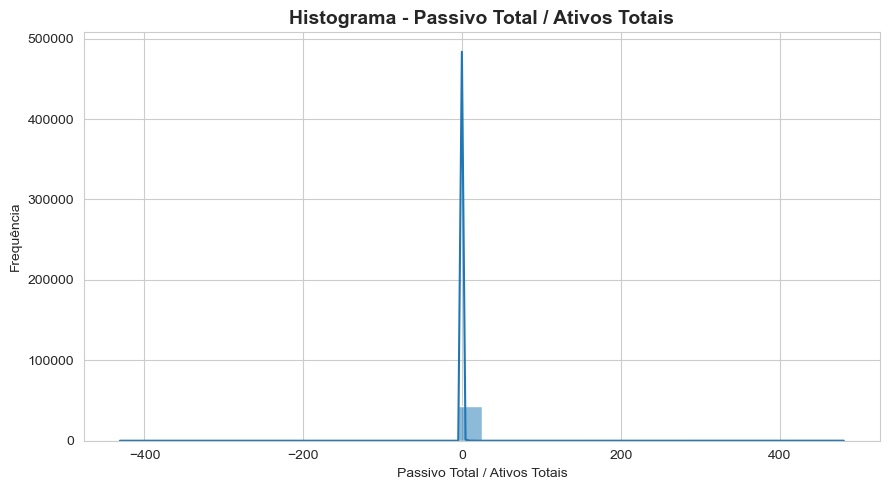

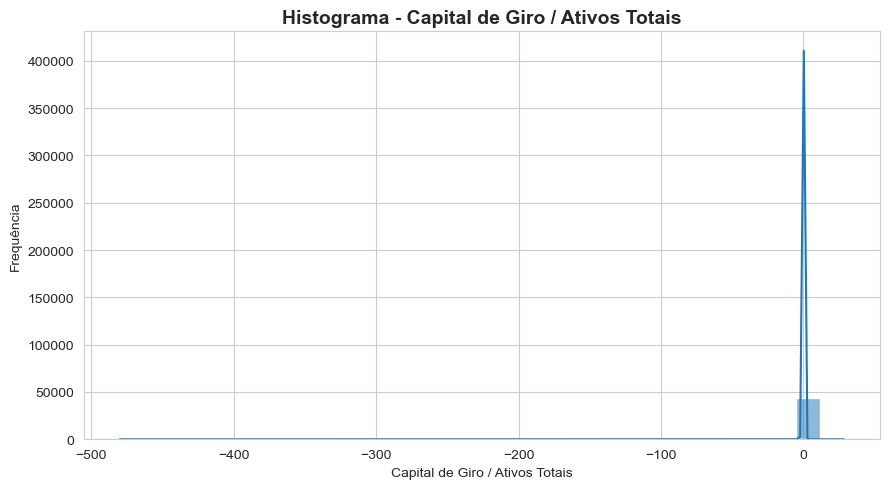

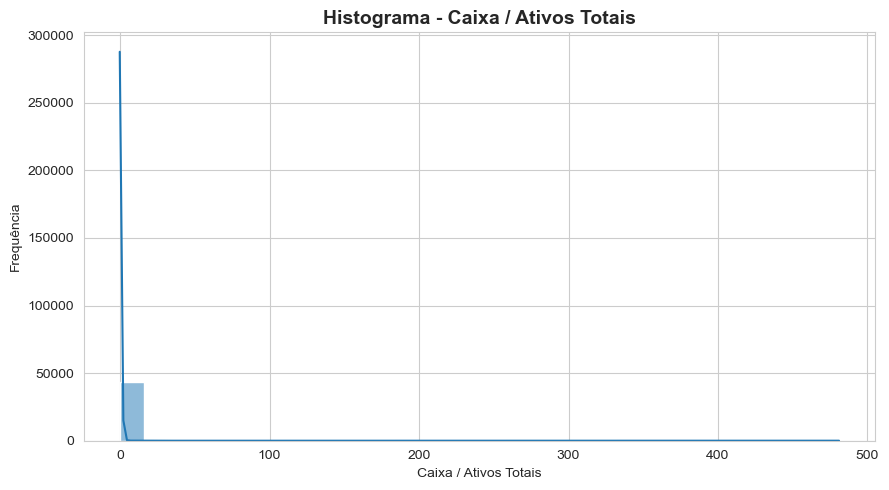

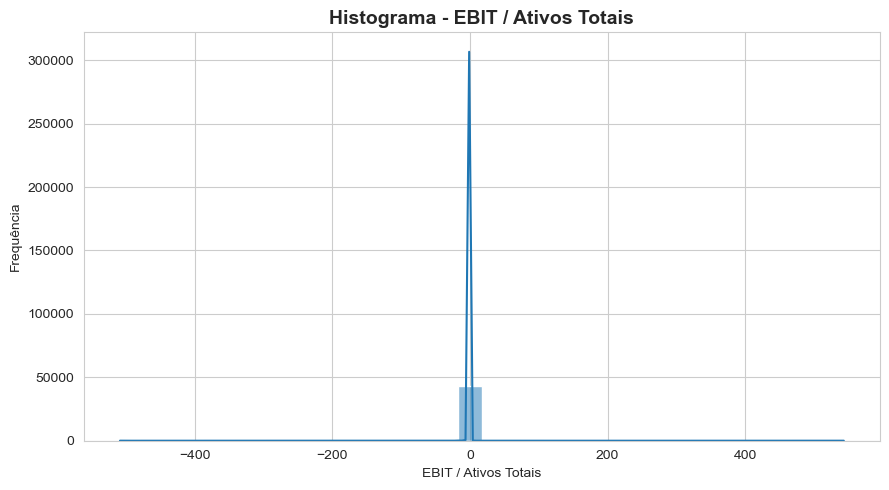

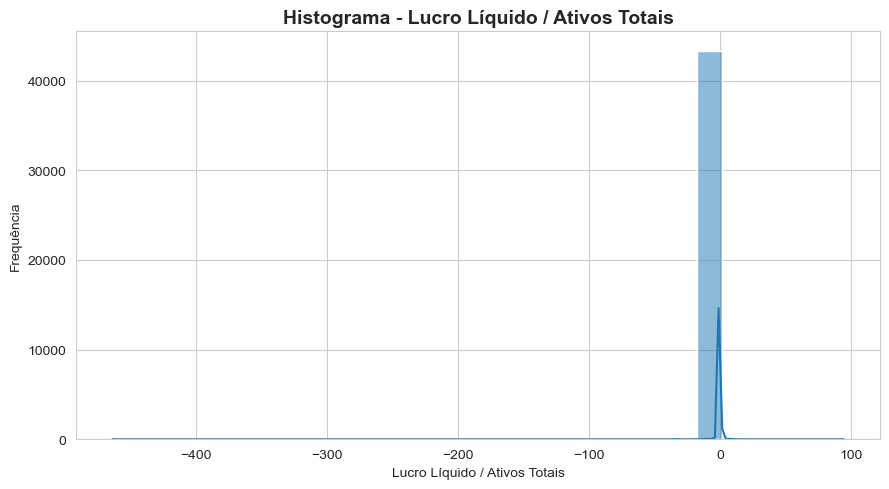

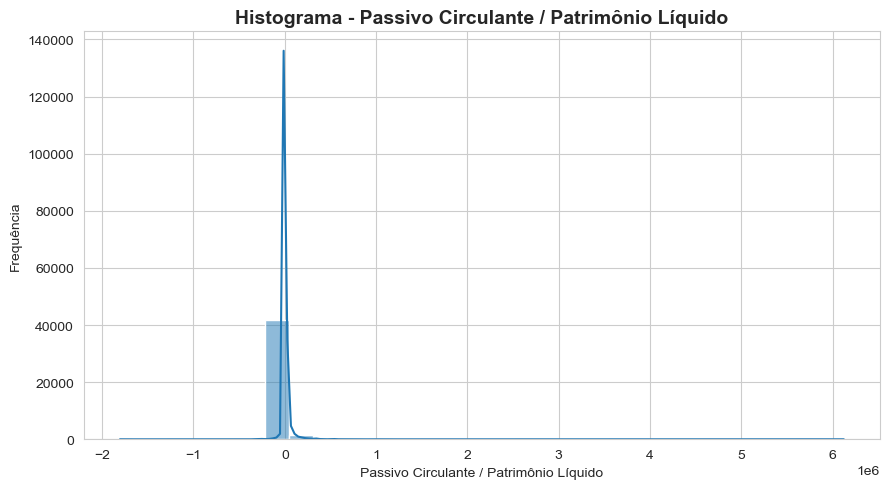

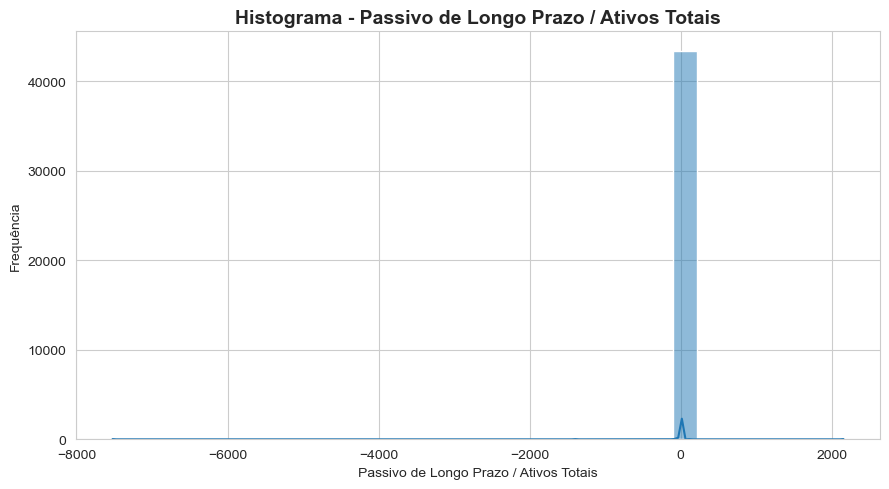

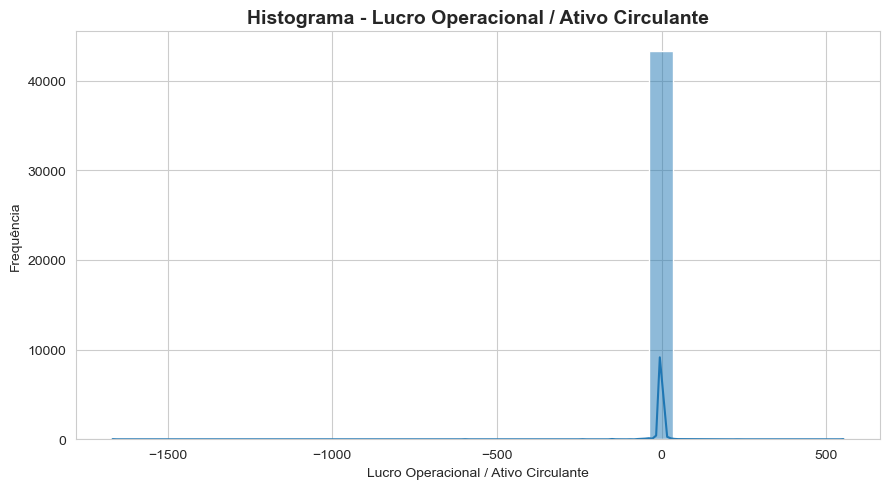

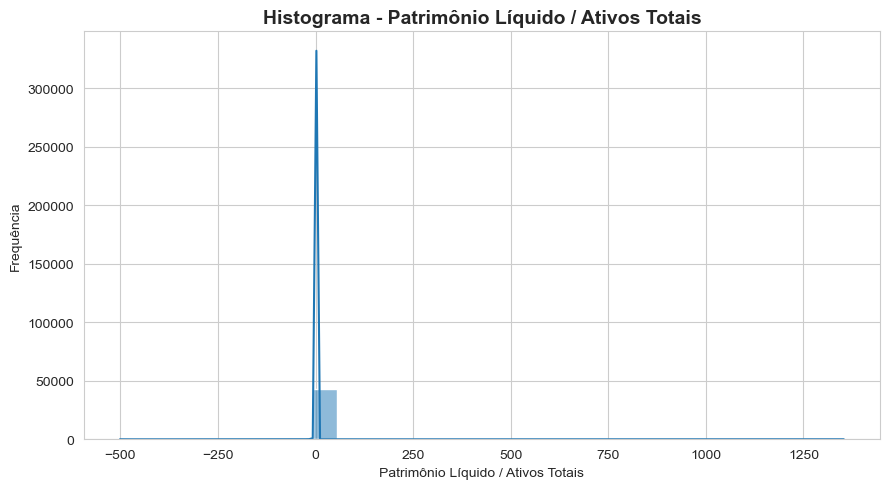

In [12]:
# HISTOGRAMAS DAS 15 PRINCIPAIS VARIÁVEIS

df = df.loc[:, ~df.columns.duplicated()].copy()

df["Situação da Empresa"] = df["Situação da Empresa"].astype(int)

correlation = df.corr(numeric_only=True)

target_corr = (
    correlation["Situação da Empresa"]
    .drop("Situação da Empresa")
    .abs()
    .sort_values(ascending=False)
)

principais_variaveis = list(target_corr.head(10).index)


sns.set_style("whitegrid")

for col in principais_variaveis:
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

    plt.figure(figsize=(9, 5))

    sns.histplot(
        df[col].dropna(),
        kde=True,
        bins=30
    )

    plt.title(
        f"Histograma - {col}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequência")

    plt.tight_layout()
    plt.show()

Essas características mostram que empresas falidas e não falidas podem apresentar comportamentos distintos em determinados atributos, reforçando a importância dessas variáveis para a previsão de insolvência.

Top 5 variáveis mais correlacionadas com falência:
['Logaritmo do Ativo Total', 'Passivo Total / Ativos Totais', 'Capital de Giro / Ativos Totais', 'Caixa / Ativos Totais', 'EBIT / Ativos Totais']


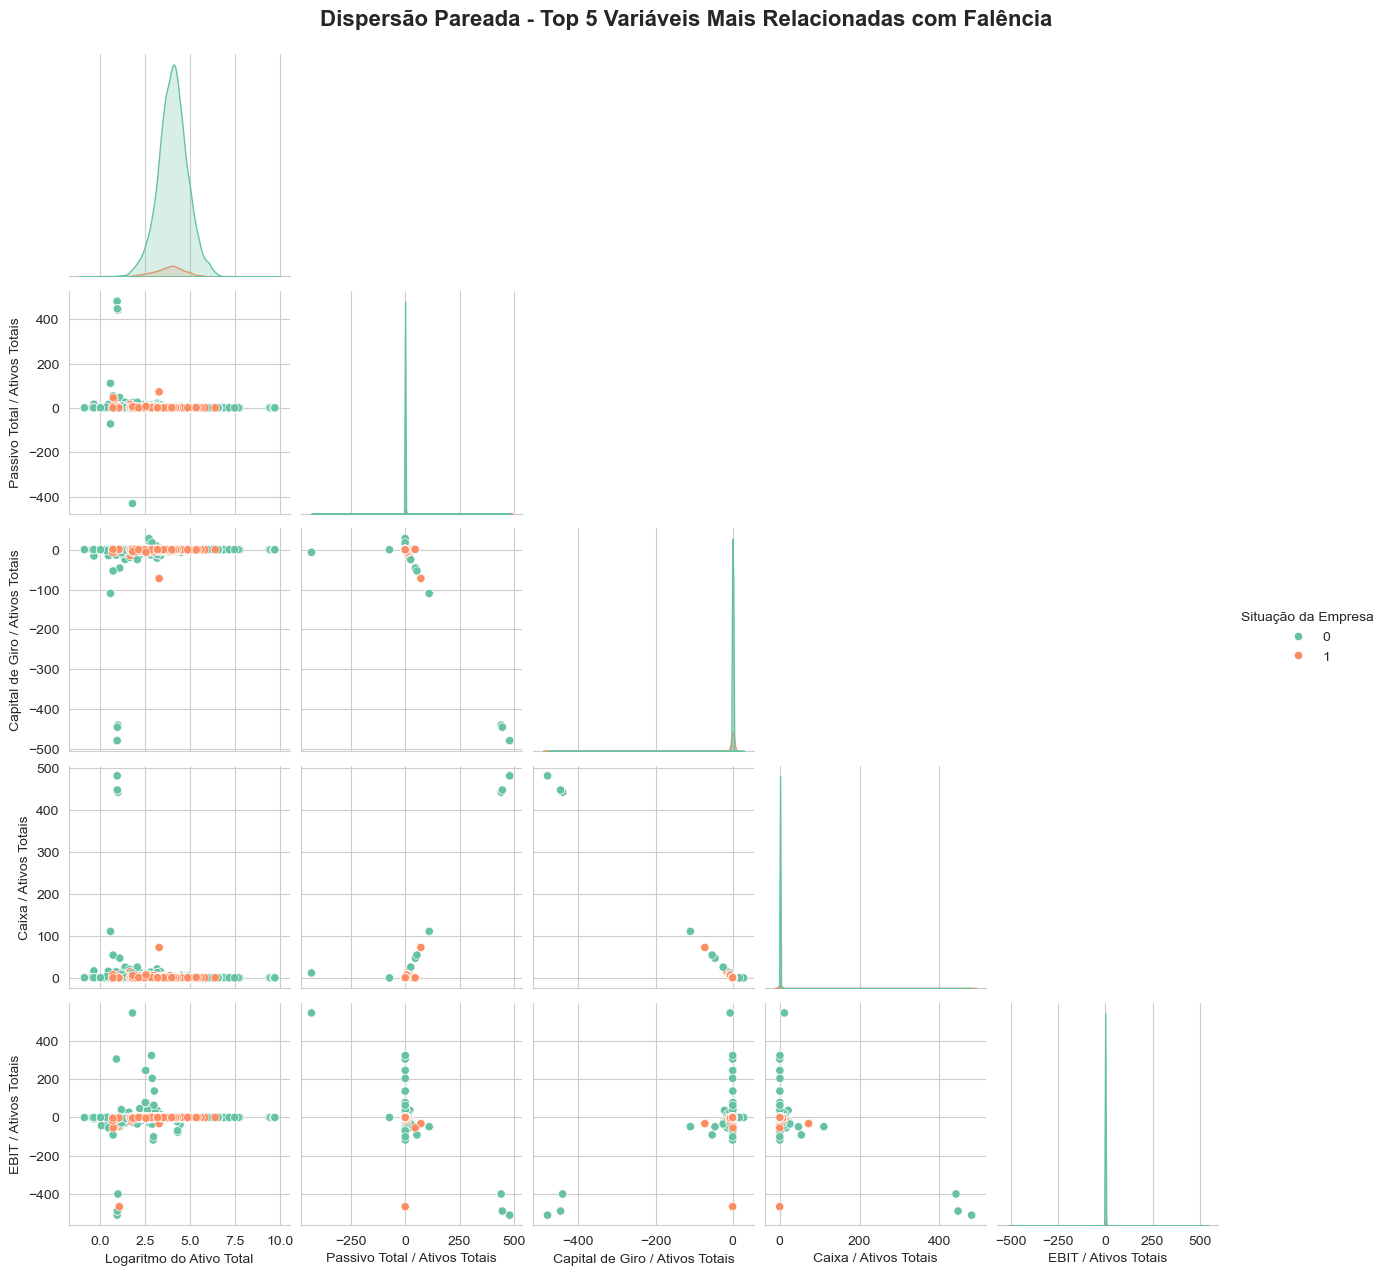

In [13]:
# DISPERSÃO PAREADA 

df = df.loc[:, ~df.columns.duplicated()].copy()
df["Situação da Empresa"] = df["Situação da Empresa"].astype(int)

correlation = df.corr(numeric_only=True)

target_corr = (
    correlation["Situação da Empresa"]
    .drop("Situação da Empresa")
    .abs()
    .sort_values(ascending=False)
)

top_5_cols = list(target_corr.head(5).index)

print("Top 5 variáveis mais correlacionadas com falência:")
print(top_5_cols)

df_pairplot = df[top_5_cols + ["Situação da Empresa"]].copy()

for col in top_5_cols:
    df_pairplot[col] = pd.to_numeric(df_pairplot[col], errors="coerce")

df_pairplot = df_pairplot.dropna()

sns.set_style("whitegrid")
sns.pairplot(
    data=df_pairplot,
    vars=top_5_cols,
    hue="Situação da Empresa",
    palette="Set2",
    diag_kind="kde",
    corner=True
)

plt.suptitle(
    "Dispersão Pareada - Top 5 Variáveis Mais Relacionadas com Falência",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)

plt.show()

Duas variáveis mais importantes:
['Logaritmo do Ativo Total', 'Passivo Total / Ativos Totais']


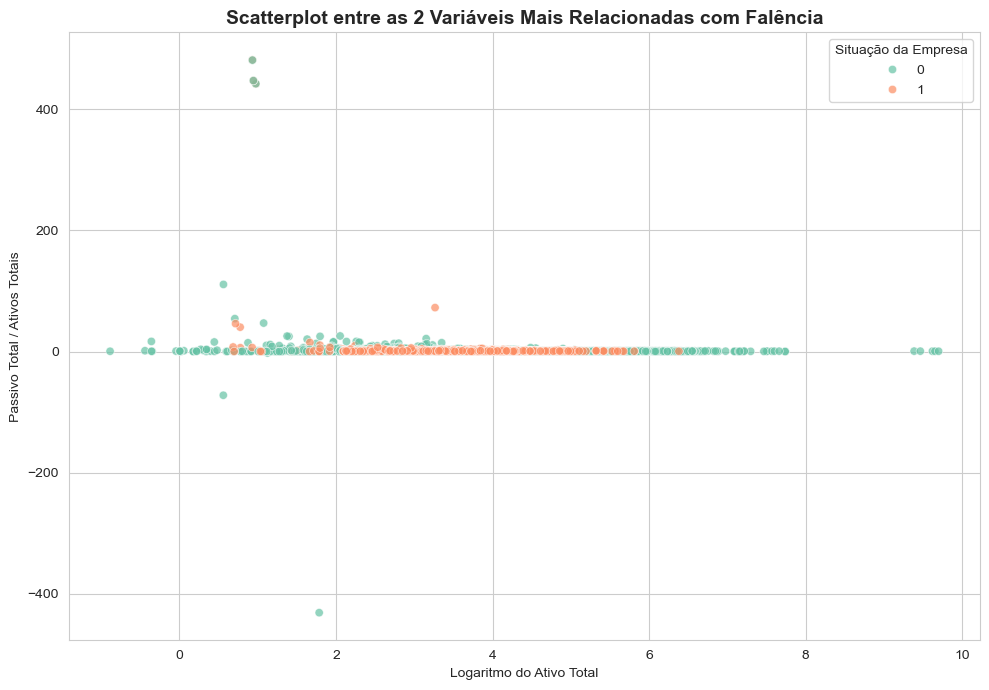

In [14]:
# 19. SCATTERPLOT ENTRE DUAS VARIÁVEIS IMPORTANTES

df = df.loc[:, ~df.columns.duplicated()].copy()

df["Situação da Empresa"] = df["Situação da Empresa"].astype(int)

correlation = df.corr(numeric_only=True)

target_corr = (
    correlation["Situação da Empresa"]
    .drop("Situação da Empresa")
    .abs()
    .sort_values(ascending=False)
)

top_2_cols = list(target_corr.head(2).index)

print("Duas variáveis mais importantes:")
print(top_2_cols)

for col in top_2_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df_scatter = df[top_2_cols + ["Situação da Empresa"]].dropna()

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_scatter,
    x=top_2_cols[0],
    y=top_2_cols[1],
    hue="Situação da Empresa",
    palette="Set2",
    alpha=0.7
)

plt.title(
    "Scatterplot entre as 2 Variáveis Mais Relacionadas com Falência",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(top_2_cols[0])
plt.ylabel(top_2_cols[1])

plt.legend(title="Situação da Empresa")
plt.tight_layout()
plt.show()

In [15]:
# TOTAL DE EMPRESAS SOMANDO OS 5 ARQUIVOS CSV
arquivo1 = pd.read_csv("1year.csv", na_values="?")
arquivo2 = pd.read_csv("2year.csv", na_values="?")
arquivo3 = pd.read_csv("3year.csv", na_values="?")
arquivo4 = pd.read_csv("4year.csv", na_values="?")
arquivo5 = pd.read_csv("5year.csv", na_values="?")

total_1 = arquivo1.shape[0]
total_2 = arquivo2.shape[0]
total_3 = arquivo3.shape[0]
total_4 = arquivo4.shape[0]
total_5 = arquivo5.shape[0]

total_empresas = total_1 + total_2 + total_3 + total_4 + total_5

print("Quantidade de empresas por arquivo:\n")

print(f"1year.csv → {total_1} empresas")
print(f"2year.csv → {total_2} empresas")
print(f"3year.csv → {total_3} empresas")
print(f"4year.csv → {total_4} empresas")
print(f"5year.csv → {total_5} empresas")

print("\n==============================")
print(f"TOTAL GERAL: {total_empresas} empresas")
print("==============================")

Quantidade de empresas por arquivo:

1year.csv → 7027 empresas
2year.csv → 10173 empresas
3year.csv → 10503 empresas
4year.csv → 9792 empresas
5year.csv → 5910 empresas

TOTAL GERAL: 43405 empresas


Total de registros analisados: 43405


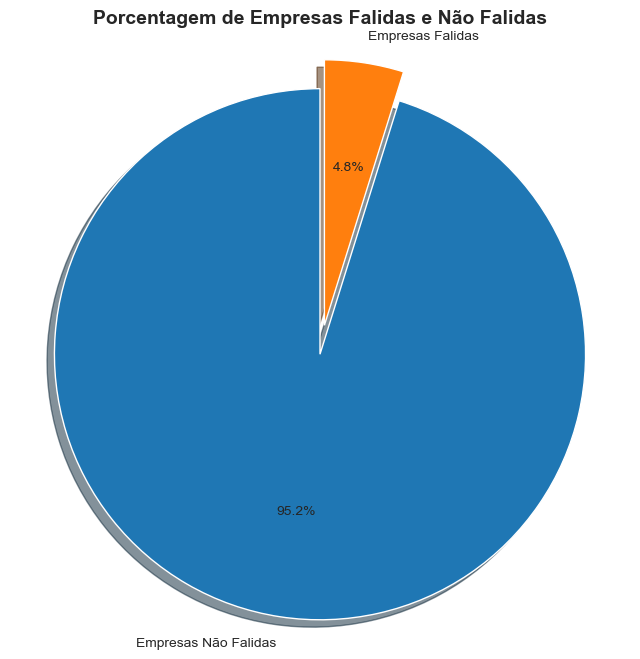

In [16]:
# GRÁFICO DE PIZZA
# PORCENTAGEM DE EMPRESAS FALIDAS E NÃO FALIDAS
arquivo1 = pd.read_csv("1year.csv", na_values="?")
arquivo2 = pd.read_csv("2year.csv", na_values="?")
arquivo3 = pd.read_csv("3year.csv", na_values="?")
arquivo4 = pd.read_csv("4year.csv", na_values="?")
arquivo5 = pd.read_csv("5year.csv", na_values="?")

df = pd.concat(
    [arquivo1, arquivo2, arquivo3, arquivo4, arquivo5],
    ignore_index=True
)

print("Total de registros analisados:", df.shape[0])

distribuicao = df["class"].value_counts()

labels = [
    "Empresas Não Falidas",
    "Empresas Falidas"
]

valores = [
    distribuicao.get(0, 0),
    distribuicao.get(1, 0)
]

plt.figure(figsize=(8, 8))

plt.pie(
    valores,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.03, 0.08),
    shadow=True
)

plt.title(
    "Porcentagem de Empresas Falidas e Não Falidas",
    fontsize=14,
    fontweight="bold"
)

plt.axis("equal")  
plt.show()

#### CONCLUSÃO:

A Análise Exploratória de Dados permitiu compreender
o comportamento financeiro das empresas e identificar
os principais fatores associados à falência empresarial.

Observou-se que empresas falidas apresentam,
em geral, menor liquidez, menor lucratividade
e maior nível de endividamento.

Esses padrões justificam o uso dessas variáveis
na etapa seguinte de Machine Learning,
onde serão aplicados modelos preditivos como:
- Regressão Logística
- Random Forest